In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

print(' All libraries imported successfully!')

 All libraries imported successfully!


In [19]:
df = pd.read_csv("animal_species_200_rows.csv")
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (200, 10)


,Animal Type,Animal Name,Speed,Weight,Continent,Country,Lifespan,Migration,Reproduction,Threat Level
0,Insect,WalkingStick,8,349,Africa,Australia,93,No,Live,High
1,Bird,Hornbill,32,381,Africa,Brazil,2,Yes,Eggs,Medium
2,Bird,Hornbill,93,201,Europe,Germany,32,Yes,Live,High
3,Bird,Canary,85,21,Europe,Egypt,65,No,Eggs,Critical
4,Mammal,Lemur,40,80,Africa,Brazil,11,Yes,Live,Low


In [20]:
print('Dataset Info:')
print(df.info())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Animal Type   200 non-null    object
 1   Animal Name   200 non-null    object
 2   Speed         200 non-null    int64 
 3   Weight        200 non-null    int64 
 4   Continent     200 non-null    object
 5   Country       200 non-null    object
 6   Lifespan      200 non-null    int64 
 7   Migration     200 non-null    object
 8   Reproduction  200 non-null    object
 9   Threat Level  200 non-null    object
dtypes: int64(3), object(7)
memory usage: 15.8+ KB
None

Basic Statistics:


,Speed,Weight,Lifespan
count,200.000000,200.000000,200.000000
mean,62.095000,236.315000,52.860000
std,33.318864,139.643753,29.807935
min,1.000000,1.000000,2.000000
25%,31.000000,133.750000,28.750000
50%,64.000000,218.500000,50.500000
75%,89.000000,357.250000,81.000000
max,119.000000,495.000000,100.000000


In [21]:
df_clean = df[['Speed', 'Weight', 'Lifespan']].copy()
df_clean.dropna(inplace=True)

print(f' Data cleaned!')
print(f'Rows before cleaning: {len(df)}')
print(f'Rows after cleaning:  {len(df_clean)}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
df_clean.head()

 Data cleaned!
Rows before cleaning: 200
Rows after cleaning:  200
Missing values: 0


,Speed,Weight,Lifespan
0,8,349,93
1,32,381,2
2,93,201,32
3,85,21,65
4,40,80,11


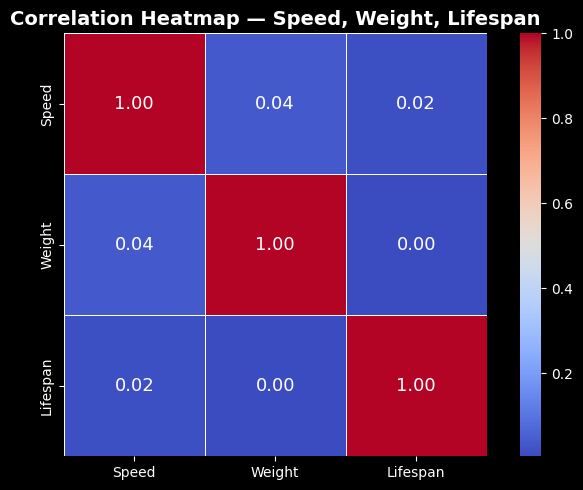


Correlation Values with Lifespan:
Speed       0.015041
Weight      0.004988
Lifespan    1.000000
Name: Lifespan, dtype: float64

Interpretation:
   Values close to +1 or -1 = Strong relationship
   Values close to 0         = Weak/No relationship


In [22]:
plt.figure(figsize=(7, 5))
corr_matrix = df_clean.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 13}
)
plt.title('Correlation Heatmap — Speed, Weight, Lifespan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation Values with Lifespan:')
print(corr_matrix['Lifespan'])
print('\nInterpretation:')
print('   Values close to +1 or -1 = Strong relationship')
print('   Values close to 0         = Weak/No relationship')

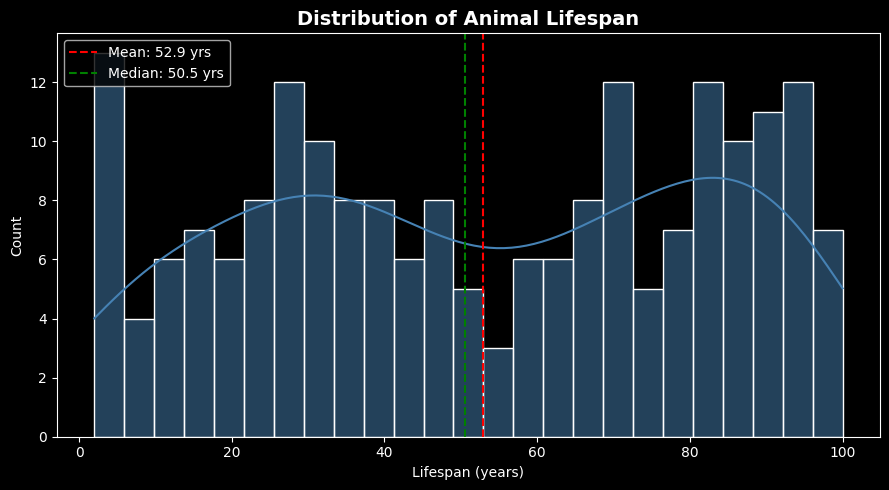

Mean Lifespan:   52.86 years
Median Lifespan: 50.50 years
Std Deviation:   29.81 years
Min / Max:       2 / 100 years


In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(df_clean['Lifespan'], bins=25, kde=True, color='steelblue', edgecolor='white')
plt.axvline(df_clean['Lifespan'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Lifespan'].mean():.1f} yrs")
plt.axvline(df_clean['Lifespan'].median(), color='green', linestyle='--', label=f"Median: {df_clean['Lifespan'].median():.1f} yrs")
plt.title('Distribution of Animal Lifespan', fontsize=14, fontweight='bold')
plt.xlabel('Lifespan (years)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean Lifespan:   {df_clean["Lifespan"].mean():.2f} years')
print(f'Median Lifespan: {df_clean["Lifespan"].median():.2f} years')
print(f'Std Deviation:   {df_clean["Lifespan"].std():.2f} years')
print(f'Min / Max:       {df_clean["Lifespan"].min()} / {df_clean["Lifespan"].max()} years')

In [24]:
X = df_clean[['Speed', 'Weight']]
y = df_clean['Lifespan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Data split done!')
print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Data split done!
Training samples: 160
Testing samples:  40


In [25]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print(' Linear Regression model trained!')

 Linear Regression model trained!


In [26]:
print('=' * 50)
print('   LINEAR REGRESSION — MODEL PARAMETERS')
print('=' * 50)
print(f'  Intercept  : {linear_model.intercept_:.4f}')
print(f'  Coeff Speed: {linear_model.coef_[0]:.4f}  (per 1 km/h increase)')
print(f'  Coeff Weight: {linear_model.coef_[1]:.4f}  (per 1 kg increase)')
print('=' * 50)
print()
print(' Explanation:')
print(f'  • The Intercept ({linear_model.intercept_:.2f}) is the predicted lifespan')
print(f'    when both Speed = 0 and Weight = 0.')
print(f'  • Speed coefficient ({linear_model.coef_[0]:.4f}): For every 1 km/h increase')
print(f'    in speed, lifespan changes by this amount.')
print(f'  • Weight coefficient ({linear_model.coef_[1]:.4f}): For every 1 kg increase')
print(f'    in weight, lifespan changes by this amount.')

   LINEAR REGRESSION — MODEL PARAMETERS
  Intercept  : 55.7692
  Coeff Speed: -0.0406  (per 1 km/h increase)
  Coeff Weight: -0.0032  (per 1 kg increase)

 Explanation:
  • The Intercept (55.77) is the predicted lifespan
    when both Speed = 0 and Weight = 0.
  • Speed coefficient (-0.0406): For every 1 km/h increase
    in speed, lifespan changes by this amount.
  • Weight coefficient (-0.0032): For every 1 kg increase
    in weight, lifespan changes by this amount.


In [27]:
poly_converter = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly_converter.fit_transform(X_train)
X_test_poly  = poly_converter.transform(X_test)

print('Polynomial features created!')
print(f'Original features:    {X_train.shape[1]}')
print(f'Polynomial features:  {X_train_poly.shape[1]}')
print(f'Feature names: {poly_converter.get_feature_names_out(["Speed", "Weight"])}')

Polynomial features created!
Original features:    2
Polynomial features:  5
Feature names: ['Speed' 'Weight' 'Speed^2' 'Speed Weight' 'Weight^2']


In [28]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print('Polynomial Regression model trained!')

Polynomial Regression model trained!


In [29]:
y_pred_linear = linear_model.predict(X_test)
y_pred_poly   = poly_model.predict(X_test_poly)

r2_linear = r2_score(y_test, y_pred_linear)
r2_poly   = r2_score(y_test, y_pred_poly)

print('=' * 50)
print('         MODEL ACCURACY REPORT (R² Score)')
print('=' * 50)
print(f'  Linear Regression R²    : {r2_linear:.4f}')
print(f'  Polynomial Regression R²: {r2_poly:.4f}')
print('=' * 50)
print()
print('Note: R² = 1.0 is a perfect model.')
print('         R² near 0 or negative means poor prediction.')

if r2_poly > r2_linear:
    print(f'\n Winner: Polynomial Model (R² = {r2_poly:.4f})')
else:
    print(f'\n Winner: Linear Model (R² = {r2_linear:.4f})')

         MODEL ACCURACY REPORT (R² Score)
  Linear Regression R²    : -0.0305
  Polynomial Regression R²: -0.0883

Note: R² = 1.0 is a perfect model.
         R² near 0 or negative means poor prediction.

 Winner: Linear Model (R² = -0.0305)


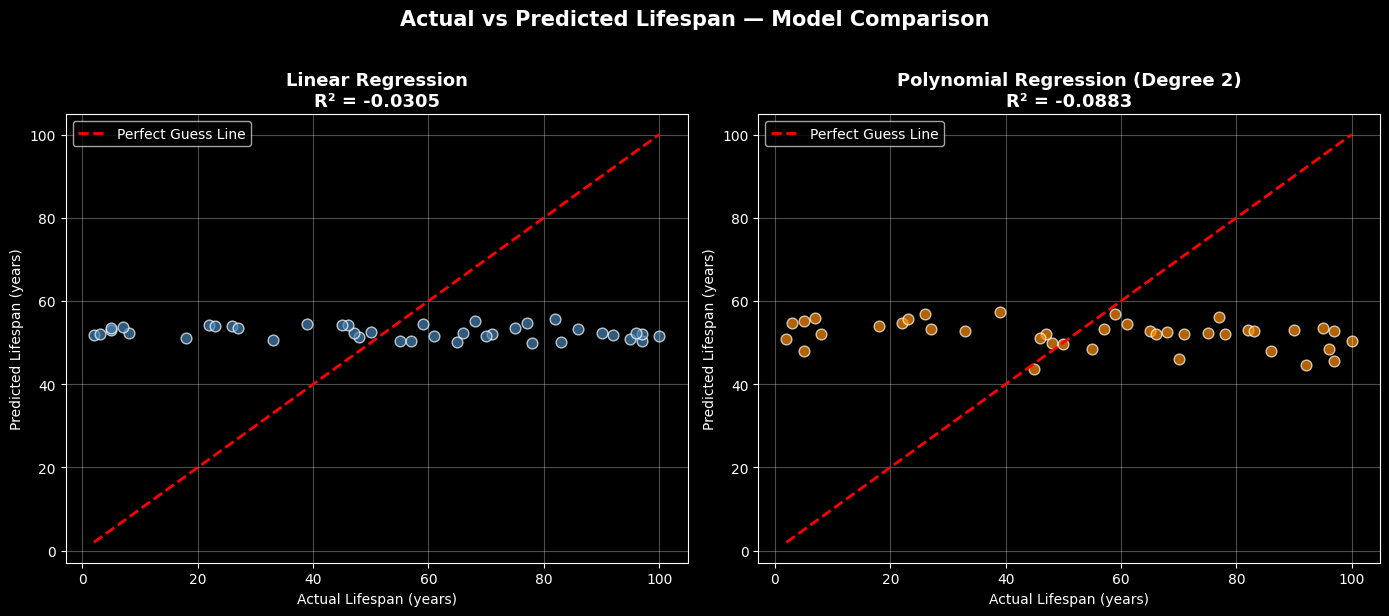

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
all_vals = np.concatenate([y_test, y_pred_linear, y_pred_poly])
line_min, line_max = all_vals.min(), all_vals.max()

axes[0].scatter(y_test, y_pred_linear, color='steelblue', alpha=0.7, edgecolor='white', s=60)
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Perfect Guess Line')
axes[0].set_title(f'Linear Regression\nR² = {r2_linear:.4f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Lifespan (years)')
axes[0].set_ylabel('Predicted Lifespan (years)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_poly, color='darkorange', alpha=0.7, edgecolor='white', s=60)
axes[1].plot([line_min, line_max], [line_min, line_max], 'r--', lw=2, label='Perfect Guess Line')
axes[1].set_title(f'Polynomial Regression (Degree 2)\nR² = {r2_poly:.4f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Lifespan (years)')
axes[1].set_ylabel('Predicted Lifespan (years)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Lifespan — Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
with open('linear_model.pkl', 'wb') as f:
    pickle.dump(linear_model, f)
print(' linear_model.pkl saved!')

with open('poly_model.pkl', 'wb') as f:
    pickle.dump(poly_model, f)
print(' poly_model.pkl saved!')

with open('poly_converter.pkl', 'wb') as f:
    pickle.dump(poly_converter, f)
print(' poly_converter.pkl saved!')

print('\n All 3 model files saved successfully!')

 linear_model.pkl saved!
 poly_model.pkl saved!
 poly_converter.pkl saved!

 All 3 model files saved successfully!


In [32]:
with open('linear_model.pkl', 'rb') as f:
    loaded_linear = pickle.load(f)

with open('poly_model.pkl', 'rb') as f:
    loaded_poly = pickle.load(f)

with open('poly_converter.pkl', 'rb') as f:
    loaded_converter = pickle.load(f)

sample = pd.DataFrame({'Speed': [60], 'Weight': [150]})
sample_poly = loaded_converter.transform(sample)

pred_lin  = loaded_linear.predict(sample)[0]
pred_poly = loaded_poly.predict(sample_poly)[0]

print(' Test Prediction for: Speed=60 km/h, Weight=150 kg')
print(f'   Linear Model Prediction:     {pred_lin:.2f} years')
print(f'   Polynomial Model Prediction: {pred_poly:.2f} years')
print('\nModels loaded and verified successfully!')

 Test Prediction for: Speed=60 km/h, Weight=150 kg
   Linear Model Prediction:     52.85 years
   Polynomial Model Prediction: 54.76 years

Models loaded and verified successfully!


Short Summary — Why is R² Score Low?

The R² scores for both models are likely low because *Speed and Weight are weak predictors of Lifespan* in this dataset. A heavy animal does not necessarily live longer — for example, a whale is very heavy and long-lived, but an elephant is also heavy yet lives a different number of years, while a small tortoise can outlive both. The data is *highly spread out* with no consistent pattern between weight/speed and lifespan. Additionally, lifespan is influenced by many other factors not in this dataset, such as diet, habitat, predators, and genetics. Because the relationship between these two features and lifespan is neither linear nor clearly curved, even a Polynomial model cannot capture the real-world complexity.